In [1]:
knitr::opts_chunk$set(echo = TRUE)
library(glue)
library(ggplot2)
library(tseries)
library(tidyr)
library(urca)
library(vars)
library(aod)
library(zoo)
library(dplyr)


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: MASS

Loading required package: strucchange

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: lmtest


Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
source('gmc_src/GMC.R')
source('gmc_src/Equality.R')

KernSmooth 2.23 loaded
Copyright M. P. Wand 1997-2009

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: sgeostat

This build of rgl does not include OpenGL functions.  Use
 rglwidget() to display results, e.g. via options(rgl.printRglwidget = TRUE).



In [3]:
centrality_measures = c('betweenness', 'closeness', 'clusterrank',
    'constraint', 'degree', 'diffusion','dmnc',
    'hubs', 'laplacian', 'lobby', 'mnc',
    'pagerank', 'topocoefficient', 'transitivity')

frequency_measures = c('zipf')


sd_measures = c('spectral_diversity', 'nonzero_eigenvalues', 'entropy', 'condition_number')

antonyms_df = read.csv("gmc_src/antonyms_with_network_properties.csv")
metrics_df = read.csv("gmc_src/words_metrics_long_df.csv")

set.seed(42)  # Set seed for reproducibility
#jitter_amount <- runif(nrow(metrics_df), min = -0.05, max = 0.05)
#metrics_df$nonzero_eigenvalues <- metrics_df$nonzero_eigenvalues + jitter_amount




random_word_order <- metrics_df %>%
  distinct(word) %>%
  mutate(rand = runif(n())) %>%
  arrange(rand) %>%
  dplyr::select(word)

# 3. Join this random order back to 'metrics_df' and arrange by 'rand'
metrics_df_random <- metrics_df %>%
  inner_join(random_word_order %>% mutate(rand_order = row_number()), by = "word") %>%
  arrange(rand_order) %>%
  dplyr::select(-rand_order)

metrics_df$random_measure <- runif(nrow(metrics_df), min = 0, max = 1)

# Now 'metrics_df_random' has all rows for each word in a single, consistent random position

# ---- If you need a quick check:
head(metrics_df_random)

# 4. Create decade-based column dictionaries for original vs. randomized data
unique_decades <- unique(metrics_df$decade)
column_dicts_set <- list()

for (decade in unique_decades) {
  subset_df <- metrics_df[metrics_df$decade == decade, ]
  column_dict <- lapply(subset_df, as.list)
  names(column_dict) <- names(subset_df)
  column_dicts_set[[paste0("column_dict_", decade)]] <- column_dict
}

unique_decades_random <- unique(metrics_df_random$decade)
column_dicts_random_set <- list()

for (decade in unique_decades_random) {
  subset_df_random <- metrics_df_random[metrics_df_random$decade == decade, ]
  column_dict_random <- lapply(subset_df_random, as.list)
  names(column_dict_random) <- names(subset_df_random)
  column_dicts_random_set[[paste0("column_dict_", decade)]] <- column_dict_random
}

,word,decade,betweenness,closeness,clusterrank,constraint,degree,diffusion,dmnc,hubs,⋯,lobby,mnc,pagerank,topocoefficient,transitivity,zipf,spectral_diversity,nonzero_eigenvalues,entropy,condition_number
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,unfair,1820,0.000000e+00,0.3639409,253706.0,0.007618547,0.01231195,696536,2.834837,0.06114187,⋯,170,169,2.138588e-05,0.08573144,0.3643280,3.488814,32.74990,8,0.9711643,12.432673
2,unfair,1830,1.499128e-07,0.3813037,317123.4,0.003733816,0.02785141,1262140,2.641080,0.10894379,⋯,376,393,3.971524e-05,0.06105001,0.2513372,3.603549,23.67659,1,0.7179758,8.117734
3,unfair,1840,1.016882e-08,0.3775107,265778.0,0.005255401,0.01839638,917628,2.700407,0.07067368,⋯,256,258,2.474348e-05,0.06994123,0.2897174,3.541916,33.83945,8,1.0297058,9.949971
4,unfair,1850,9.907849e-08,0.3874331,339304.8,0.003965529,0.02428209,1270010,2.642094,0.08893477,⋯,340,345,2.652909e-05,0.06990127,0.2672396,3.578424,34.12160,8,1.1750026,10.769073
5,unfair,1860,5.371908e-08,0.3870199,309139.7,0.004490339,0.02180294,1111082,2.609272,0.08661712,⋯,309,311,2.568552e-05,0.06798322,0.2783114,3.686966,32.08530,6,0.9219049,11.853761
6,unfair,1870,3.808345e-07,0.3884816,339477.2,0.003697384,0.02686940,1311792,2.542953,0.09779340,⋯,383,386,2.747297e-05,0.06368256,0.2588655,3.795260,43.97454,7,1.2599971,16.157654


In [4]:
gmc_df = read.csv("gmc_results_final.csv")

In [5]:
gmc_df

key,denote1,denote2,pvalue,warning,t1,t2
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
betweenness_1820_~_betweenness_1830,0.7848751,0.80083716,0.61360061,Data contain duplicated values: LSCV is not well-behaved in this case,-1.222953e-01,-1.261343e-01
betweenness_1820_~_zipf_1830,0.9900000,0.60594915,0.00000000,Data contain duplicated values: LSCV is not well-behaved in this case,-4.877200e-01,-5.393252e-12
betweenness_1820_~_spectral_diversity_1830,0.9900000,0.41143563,0.00000000,NA,-4.991487e-01,-4.222830e-12
betweenness_1820_~_entropy_1830,0.9900000,0.07961997,0.00000000,NA,-2.405748e-01,-9.737615e-13
zipf_1820_~_betweenness_1830,0.6217836,0.04454841,0.96619738,Data contain duplicated values: LSCV is not well-behaved in this case,-5.326928e-12,-6.794704e-03
zipf_1820_~_zipf_1830,0.6081098,0.60729827,0.05057517,NA,-1.743175e-01,-1.394099e-01
zipf_1820_~_spectral_diversity_1830,0.5695894,0.56123156,0.88006318,NA,-8.695147e-03,-9.870337e-03
zipf_1820_~_entropy_1830,0.3161603,0.30212945,0.49268329,NA,-4.096014e-02,-7.913469e-02
spectral_diversity_1820_~_betweenness_1830,0.4021603,0.03900545,0.61779860,Data contain duplicated values: LSCV is not well-behaved in this case,-4.029812e-12,-5.879347e-03


In [47]:
# Compute global mean and SD of spectral_diversity
spec_mean <- mean(metrics_df_random$spectral_diversity, na.rm = TRUE)
spec_sd <- sd(metrics_df_random$spectral_diversity, na.rm = TRUE)

# Add z-scored spectral_diversity
metrics_df_random <- metrics_df_random %>%
  mutate(spectral_diversity_z = (spectral_diversity - spec_mean) / spec_sd)

# Get z-scored spectral_diversity for "small" in 1850 and 2000
z_change <- metrics_df_random %>%
  filter(word == "small", decade %in% c(1850, 2000)) %>%
  select(decade, spectral_diversity_z) %>%
  arrange(decade)

# Compute and print the change
if (nrow(z_change) == 2) {
  delta_z <- z_change$spectral_diversity_z[z_change$decade == 2000] - 
             z_change$spectral_diversity_z[z_change$decade == 1850]
  cat("Z-scored change in spectral_diversity for 'small' from 1850 to 2000:", round(delta_z, 4), "\n")
} else {
  cat("Missing z-score data for 'small' in either 1850 or 2000.\n")
}


Z-scored change in spectral_diversity for 'small' from 1850 to 2000: 1.4549 


In [41]:
n_distinct(metrics_df$word)


[1] 350

In [6]:
gmc_df[gmc_df$key == "betweenness_1820_~_zipf_1830", ]


,key,denote1,denote2,pvalue,warning,t1,t2
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
2,betweenness_1820_~_zipf_1830,0.99,0.6059492,0,Data contain duplicated values: LSCV is not well-behaved in this case,-0.48772,-5.393252e-12


In [7]:
gmc_df[gmc_df$key == "zipf_1820_~_betweenness_1830", ]


,key,denote1,denote2,pvalue,warning,t1,t2
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
5,zipf_1820_~_betweenness_1830,0.6217836,0.04454841,0.9661974,Data contain duplicated values: LSCV is not well-behaved in this case,-5.326928e-12,-0.006794704


In [8]:
plot_directional_gmc_by_interval <- function(gmc_df,
                                             var_x,
                                             var_y,
                                             p_thresh = 0.05) {
  library(dplyr)
  library(ggplot2)
  library(stringr)

  ## build regex for the exact direction:  var_x_decade1_~_var_y_decade2
  pattern <- paste0("^",
                    str_replace_all(var_x, "_", "\\\\_"),
                    "_(\\d{4})_~_",
                    str_replace_all(var_y, "_", "\\\\_"),
                    "_(\\d{4})$")

  summary_df <- gmc_df %>%
    filter(str_detect(key, pattern)) %>%          # keep correct direction
    filter(!is.na(pvalue) & pvalue < p_thresh) %>%# apply p-value cutoff
    mutate(
      decade_x = as.numeric(str_match(key, pattern)[, 2]),
      decade_y = as.numeric(str_match(key, pattern)[, 3]),
      interval  = decade_y - decade_x,
      delta     = denote1 - denote2
    ) %>%
    group_by(interval) %>%
    summarise(avg_delta = mean(delta, na.rm = TRUE), .groups = "drop")

  if (nrow(summary_df) == 0) {
    message("No rows matched direction ‘", var_x, " -> ", var_y,
            "’ with p-value <", p_thresh, ".")
    return(invisible(NULL))
  }

  ggplot(summary_df, aes(interval, avg_delta)) +
    geom_line(size = 1.1) +
    geom_point(size = 2) +
    labs(title = paste("Avg (denote1 – denote2):", var_x, "→", var_y,
                       "\n(p <", p_thresh, ")"),
         x = "Decade gap (target – source)",
         y = "Average denote1 – denote2") +
    theme_minimal()
}



Attaching package: ‘stringr’


The following object is masked from ‘package:strucchange’:

    boundary


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


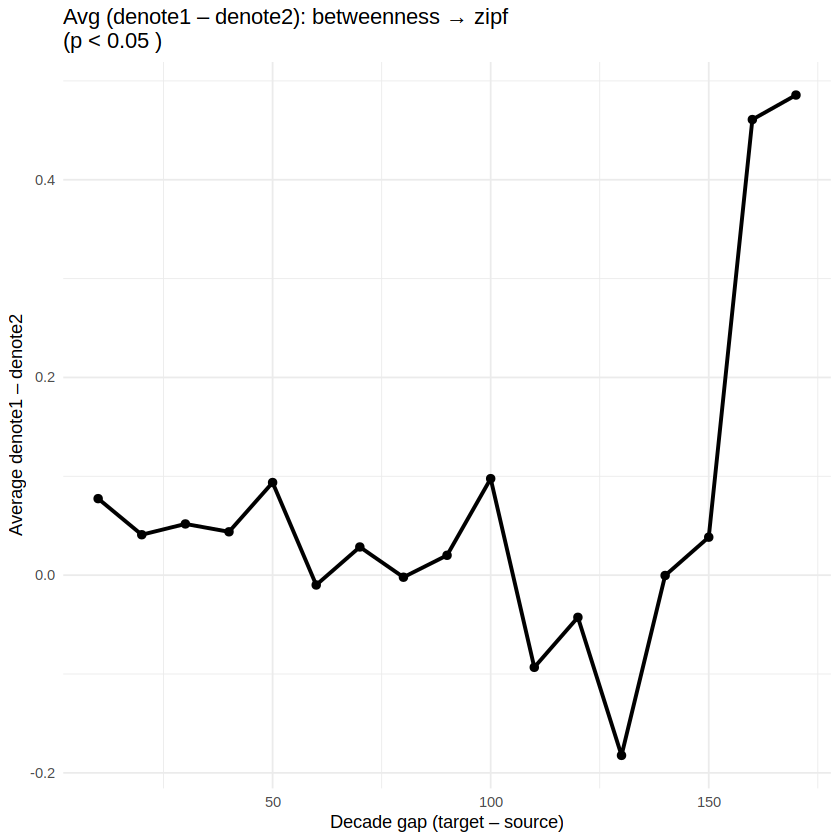

In [9]:
plot_directional_gmc_by_interval(gmc_df, "betweenness", "zipf")


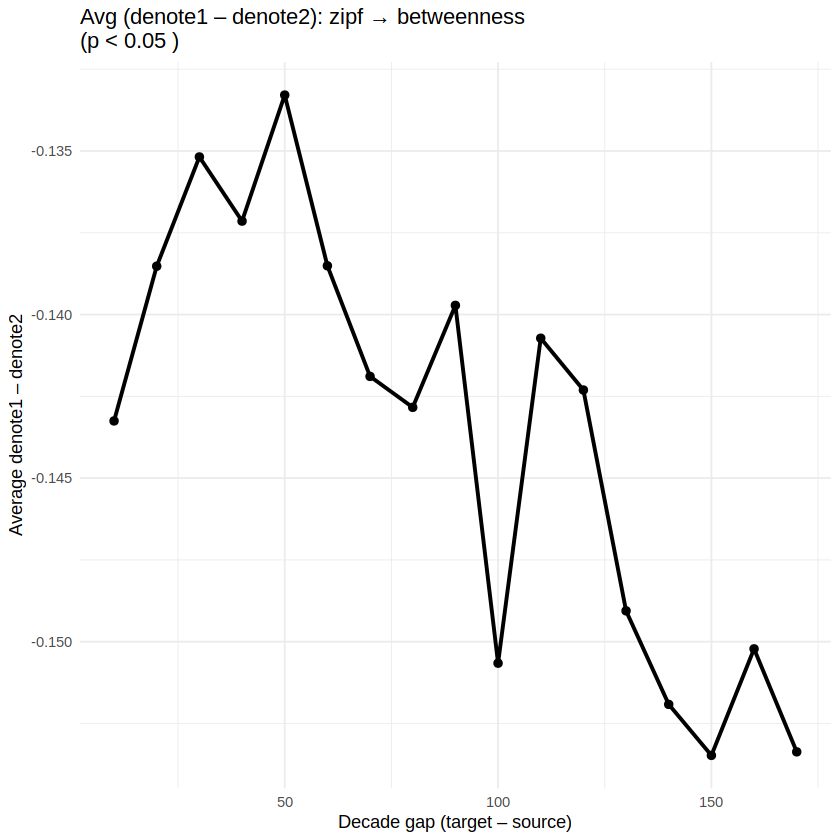

In [10]:
plot_directional_gmc_by_interval(gmc_df, "zipf", "betweenness")


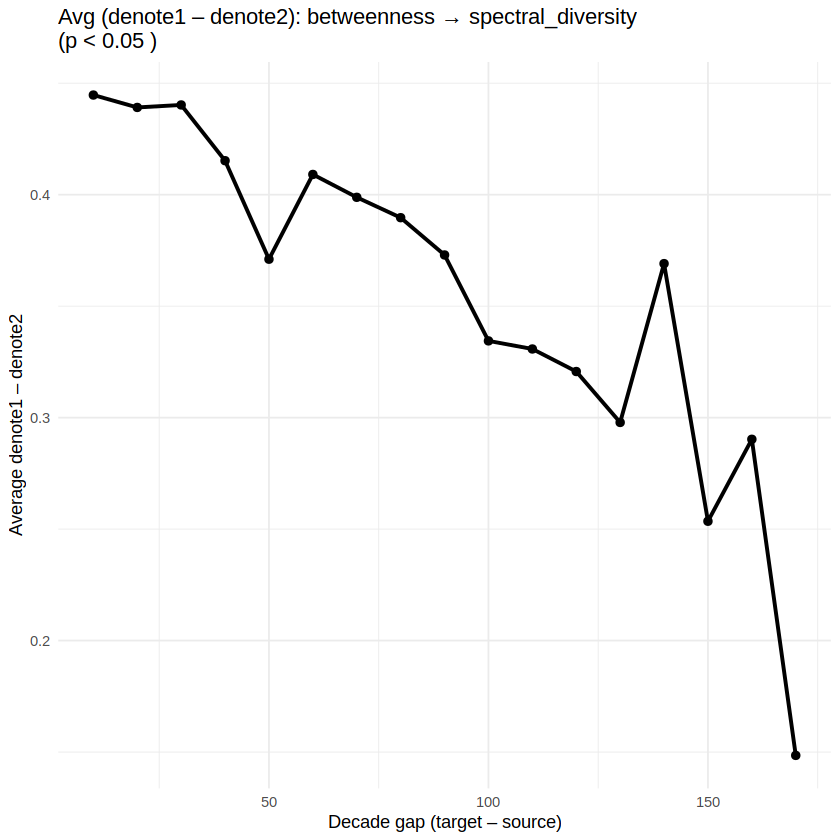

In [11]:
plot_directional_gmc_by_interval(gmc_df, "betweenness", "spectral_diversity")


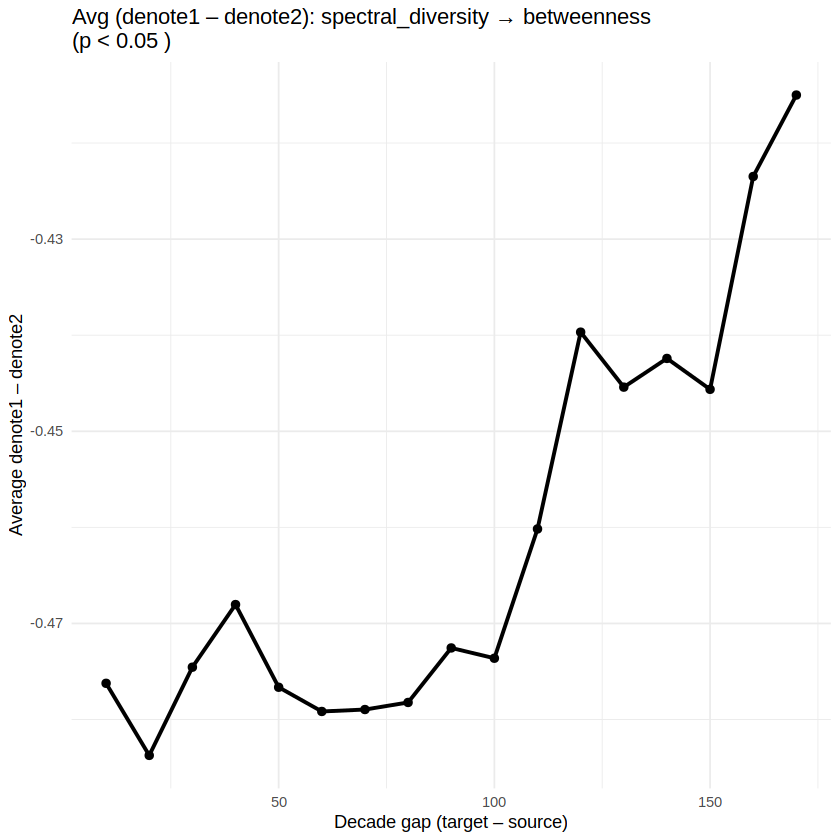

In [12]:
plot_directional_gmc_by_interval(gmc_df, "spectral_diversity", "betweenness", p=0.05)




In [5]:
plot_gmc_multiple <- function(gmc_df,
                              relation_list,
                              p_thresh = 0.05,
                              filter_warning = FALSE,
                              output_path = "gmc_plot.png") {
  library(dplyr)
  library(ggplot2)
  library(stringr)
  library(purrr)

  summarise_dir <- function(df, lhs, rhs) {
    pat <- paste0("^", lhs, "_(\\d{4})_~_", rhs, "_(\\d{4})$")

    df <- df %>%
      filter(str_detect(key, pat)) %>%
      filter(!str_detect(key, "1820"))

    if (filter_warning) {
      df <- df %>% filter(is.na(warning) | trimws(warning) == "")
    }

    df <- df %>%
      mutate(
        decade_x = as.numeric(str_match(key, pat)[, 2]),
        decade_y = as.numeric(str_match(key, pat)[, 3]),
        interval = decade_y - decade_x
      ) %>%
      filter(interval <= 150) %>%
      mutate(delta = denote1 - denote2,
             direction = paste(lhs, "→", rhs))

    sig_df <- df %>%
      filter(pvalue < 0.01) %>%
      group_by(interval, direction) %>%
      summarise(label_y = mean(delta, na.rm = TRUE) - 0.015, .groups = "drop") %>%
      mutate(star = "*")

    df <- df %>%
      filter(!is.na(pvalue) & pvalue < p_thresh)

    if (nrow(df) == 0) return(NULL)

    summary_df <- df %>%
      group_by(interval, direction) %>%
      summarise(
        avg_delta = mean(delta, na.rm = TRUE),
        avg_se    = sd(delta, na.rm = TRUE) / sqrt(n()),
        n         = n(),
        .groups = "drop"
      )

    # Print only for lag 20 and 120
    filtered_print <- summary_df %>% filter(interval %in% c(20, 120))
    if (nrow(filtered_print) > 0) {
      cat(paste0("\nEffect sizes for ", lhs, " → ", rhs, ":\n"))
      filtered_print %>%
        arrange(interval) %>%
        mutate(msg = sprintf("  Lag %3d: %.4f ± %.4f (n = %d)",
                             interval, avg_delta, avg_se, n)) %>%
        pull(msg) %>%
        writeLines()
    }

    avg_n <- round(mean(summary_df$n, na.rm = TRUE), 2)
    message("Average n for ", lhs, "→", rhs, ": ", avg_n)

    list(summary = summary_df, sig = sig_df)
  }

  results <- map(relation_list, ~ summarise_dir(gmc_df, .x[1], .x[2]))
  summaries <- bind_rows(map(results, "summary"))
  sig_labels <- bind_rows(map(results, "sig"))

  if (nrow(summaries) == 0) {
    message("No rows matched for any provided relationships.")
    return(invisible(NULL))
  }

  p <- ggplot(summaries, aes(interval, avg_delta, color = direction, fill = direction)) +
    geom_line(size = 1.1) +
    geom_point(size = 2) +
    geom_ribbon(aes(ymin = avg_delta - avg_se, ymax = avg_delta + avg_se),
                alpha = 0.2, color = NA) +
    geom_text(data = sig_labels,
              aes(x = interval, y = label_y, label = star, group = direction),
              inherit.aes = FALSE,
              size = 5) +
    labs(
      title = "Mean GMC effect size by decade gap",
      subtitle = "* = p < 0.01",
      x = "Year gap (target − source)",
      y = "Average effect size",
      color = "Direction",
      fill = "Direction"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      legend.position = "bottom",
      legend.text = element_text(size = 16),
      legend.title = element_text(size = 18),
      legend.box = "vertical",
      legend.key.width = unit(1.5, "cm")
    ) +
    guides(
      color = guide_legend(ncol = 1),
      fill = guide_legend(ncol = 1)
    )

  ggsave(output_path, plot = p, width = 7, height = 13, dpi = 300)
}


In [27]:
rels = list(c("betweenness", "zipf"),
            c("betweenness", "spectral_diversity"),
            c("zipf", "spectral_diversity"),
            c("betweenness", "entropy"),
            c("zipf", "entropy"))

plot_gmc_multiple(gmc_df,rels, p=1)





Effect sizes for betweenness → zipf:
  Lag  20: 0.0180 ± 0.0704 (n = 16)
  Lag 120: -0.1196 ± 0.1908 (n = 6)


Average n for betweenness→zipf: 10




Effect sizes for betweenness → spectral_diversity:
  Lag  20: 0.3983 ± 0.0583 (n = 16)
  Lag 120: 0.2706 ± 0.1394 (n = 6)


Average n for betweenness→spectral_diversity: 10




Effect sizes for zipf → spectral_diversity:
  Lag  20: -0.0107 ± 0.0027 (n = 16)
  Lag 120: 0.0084 ± 0.0031 (n = 6)


Average n for zipf→spectral_diversity: 10




Effect sizes for betweenness → entropy:
  Lag  20: 0.3945 ± 0.0546 (n = 16)
  Lag 120: 0.5068 ± 0.1482 (n = 6)


Average n for betweenness→entropy: 10




Effect sizes for zipf → entropy:
  Lag  20: 0.0383 ± 0.0038 (n = 16)
  Lag 120: 0.0246 ± 0.0045 (n = 6)


Average n for zipf→entropy: 10



In [ ]:
plot_gmc_pair_diffs <- function(gmc_df,
                                 relation_list,
                                 p_thresh = 0.05,
                                 filter_warning = FALSE) {
  library(dplyr)
  library(ggplot2)
  library(stringr)
  library(purrr)
  library(tidyr)

  process_pair <- function(df, lhs, rhs) {
    # Forward direction
    pat_fwd <- paste0("^", lhs, "_(\\d{4})_~_", rhs, "_(\\d{4})$")
    df_fwd <- df %>%
      filter(str_detect(key, pat_fwd)) %>%
      filter(!str_detect(key, "1820")) %>%
      mutate(
        decade_x = as.numeric(str_match(key, pat_fwd)[, 2]),
        decade_y = as.numeric(str_match(key, pat_fwd)[, 3]),
        interval = decade_y - decade_x,
        delta_fwd = denote1 - denote2
      ) %>%
      select(key, interval, delta_fwd, pvalue_fwd = pvalue, warning_fwd = warning)

    # Reverse direction
    pat_rev <- paste0("^", rhs, "_(\\d{4})_~_", lhs, "_(\\d{4})$")
    df_rev <- df %>%
      filter(str_detect(key, pat_rev)) %>%
      filter(!str_detect(key, "1820")) %>%
      mutate(
        decade_x = as.numeric(str_match(key, pat_rev)[, 2]),
        decade_y = as.numeric(str_match(key, pat_rev)[, 3]),
        interval = decade_y - decade_x,
        delta_rev = denote1 - denote2
      ) %>%
      select(key, interval, delta_rev, pvalue_rev = pvalue, warning_rev = warning)

    # Merge forward and reverse by interval
    df_joined <- full_join(df_fwd, df_rev, by = "interval") %>%
      filter(interval <= 150)

    if (filter_warning) {
      df_joined <- df_joined %>%
        filter((is.na(warning_fwd) | trimws(warning_fwd) == "") &
               (is.na(warning_rev) | trimws(warning_rev) == ""))
    }

    df_joined <- df_joined %>%
      filter(!is.na(delta_fwd) & !is.na(delta_rev)) %>%
      filter(!is.na(pvalue_fwd) & !is.na(pvalue_rev)) %>%
      filter(pvalue_fwd < p_thresh & pvalue_rev < p_thresh) %>%
      mutate(
        delta_diff = delta_fwd - delta_rev,
        direction = paste(lhs, "\u2194", rhs)  # bidirectional arrow
      )

    df_joined
  }

  # Process all pairs
  diffs_all <- map_dfr(relation_list, ~ process_pair(gmc_df, .x[1], .x[2]))

  if (nrow(diffs_all) == 0) {
    message("No valid pairs after filtering.")
    return(invisible(NULL))
  }

  # Aggregate per interval for plotting
  summary_df <- diffs_all %>%
    group_by(interval, direction) %>%
    summarise(
      avg_diff = mean(delta_diff, na.rm = TRUE),
      se = sd(delta_diff, na.rm = TRUE) / sqrt(n()),
      .groups = "drop"
    )

  # === PRINT EFFECTS AT EACH LAG ===
  cat("\nGMC Directional Effect Differences by Lag:\n")
  summary_df %>%
    arrange(direction, interval) %>%
    group_by(direction) %>%
    mutate(
      print_str = sprintf("  %s | Lag %3d: %.4f ± %.4f",
                          direction, interval, avg_diff, se)
    ) %>%
    pull(print_str) %>%
    writeLines()

  # Plot
  ggplot(summary_df, aes(x = interval, y = avg_diff, color = direction, fill = direction)) +
    geom_line(size = 1.1) +
    geom_point(size = 2) +
    geom_ribbon(aes(ymin = avg_diff - se, ymax = avg_diff + se), alpha = 0.2, color = NA) +
    labs(
      title = "Difference Between Forward and Reverse GMC Effects",
      subtitle = "Δ(fwd) - Δ(rev)",
      x = "Year gap (target − source)",
      y = "Effect size difference",
      color = "Relation",
      fill = "Relation"
    ) +
    theme_minimal()
}


Warning message in full_join(df_fwd, df_rev, by = "interval"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in full_join(df_fwd, df_rev, by = "interval"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in full_join(df_fwd, df_rev, by = "interval"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.


GMC Directional Effect Differences by Lag:
  betweenness ↔ entropy | Lag  10: 0.8422 ± 0.0143
  betweenness ↔ entropy | Lag  20: 0.7949 ± 0.0147
  betweenness ↔ entropy | Lag  30: 0.7791 ± 0.0159
  betweenness ↔ entropy | Lag  40: 0.8247 ± 0.0145
  betweenness ↔ entropy | Lag  50: 0.7996 ± 0.0170
  betweenness ↔ entropy | Lag  60: 0.7963 ± 0.0207
  betweenness ↔ entropy | Lag  70: 0.8696 ± 0.0232
  betweenness ↔ entropy | Lag  80: 0.7691 ± 0.0272
  betweenness ↔ entropy | Lag  90: 0.8652 ± 0.0310
  betweenness ↔ entropy | Lag 100: 0.7716 ± 0.0362
  betweenness ↔ entropy | Lag 110: 0.8333 ± 0.0384
  betweenness ↔ entropy | Lag 120: 0.8854 ± 0.0565
  betweenness ↔ entropy | Lag 130: 0.7431 ± 0.0653
  betweenness ↔ entropy | Lag 140: 0.6768 ± 0.1005
  betweenness ↔ entropy | Lag 150: 0.7703 ± 0.1386
  betweenness ↔ spectral_diversity | Lag  10: 0.8494 ± 0.0163
  betweenness ↔ spectral_diversity | Lag  20: 0.8131 ± 0.0198
  betweenness ↔ spectral_diversity | Lag  30: 0.8705 ± 0.0151
  bet

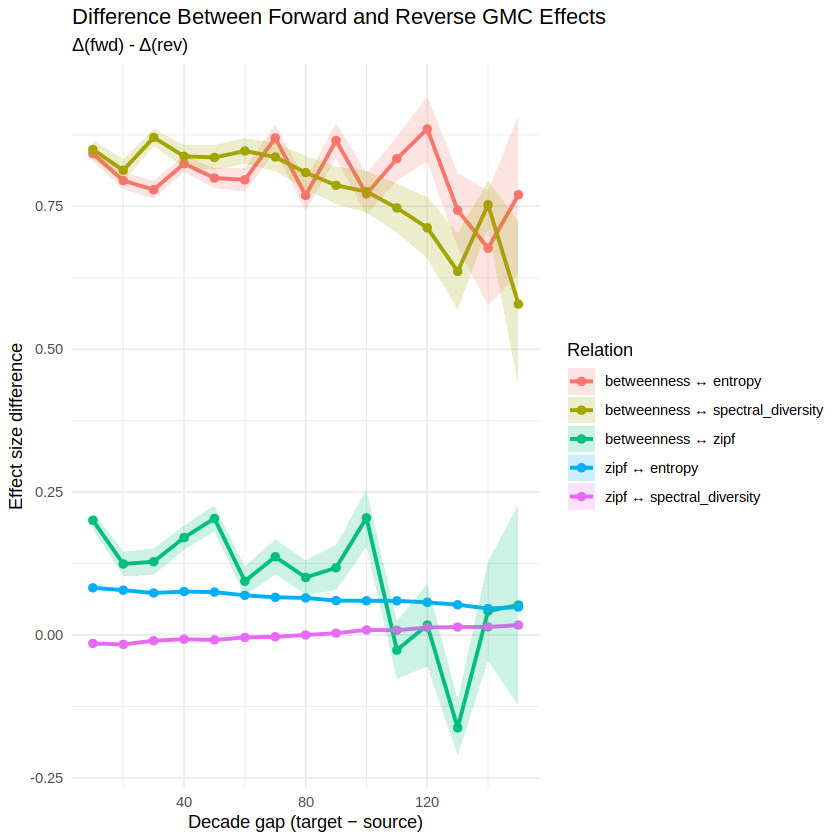

In [24]:
rels = list(c("betweenness", "zipf"),
            c("betweenness", "spectral_diversity"),
            c("zipf", "spectral_diversity"),
            c("betweenness", "entropy"),
            c("zipf", "entropy"))

plot_gmc_pair_diffs(gmc_df,rels, p=1)




In [17]:
plot_gmc_pair_diffs <- function(gmc_df,
                                 relation_list,
                                 p_thresh = 0.05,
                                 filter_warning = FALSE) {
  library(dplyr)
  library(ggplot2)
  library(stringr)
  library(purrr)
  library(tidyr)

  process_pair <- function(df, lhs, rhs) {
    # Forward direction
    pat_fwd <- paste0("^", lhs, "_(\\d{4})_~_", rhs, "_(\\d{4})$")
    df_fwd <- df %>%
      filter(str_detect(key, pat_fwd)) %>%
      filter(!str_detect(key, "1820")) %>%
      mutate(
        decade_x = as.numeric(str_match(key, pat_fwd)[, 2]),
        decade_y = as.numeric(str_match(key, pat_fwd)[, 3]),
        interval = decade_y - decade_x,
        delta_fwd = denote1 - denote2
      ) %>%
      select(key, interval, delta_fwd, pvalue_fwd = pvalue, warning_fwd = warning)

    # Reverse direction
    pat_rev <- paste0("^", rhs, "_(\\d{4})_~_", lhs, "_(\\d{4})$")
    df_rev <- df %>%
      filter(str_detect(key, pat_rev)) %>%
      filter(!str_detect(key, "1820")) %>%
      mutate(
        decade_x = as.numeric(str_match(key, pat_rev)[, 2]),
        decade_y = as.numeric(str_match(key, pat_rev)[, 3]),
        interval = decade_y - decade_x,
        delta_rev = denote1 - denote2
      ) %>%
      select(key, interval, delta_rev, pvalue_rev = pvalue, warning_rev = warning)

    # Merge forward and reverse by interval
    df_joined <- full_join(df_fwd, df_rev, by = "interval") %>%
      filter(interval <= 150)

    if (filter_warning) {
      df_joined <- df_joined %>%
        filter((is.na(warning_fwd) | trimws(warning_fwd) == "") &
               (is.na(warning_rev) | trimws(warning_rev) == ""))
    }

    df_joined <- df_joined %>%
      filter(!is.na(delta_fwd) & !is.na(delta_rev)) %>%
      filter(!is.na(pvalue_fwd) & !is.na(pvalue_rev)) %>%
      filter(pvalue_fwd < p_thresh & pvalue_rev < p_thresh) %>%
      mutate(
        delta_diff = delta_fwd - delta_rev,
        direction = paste(lhs, "\u2194", rhs)  # bidirectional arrow
      )

    df_joined
  }

  # Process all pairs
  diffs_all <- map_dfr(relation_list, ~ process_pair(gmc_df, .x[1], .x[2]))

  if (nrow(diffs_all) == 0) {
    message("No valid pairs after filtering.")
    return(invisible(NULL))
  }

  # Aggregate per interval for plotting
  summary_df <- diffs_all %>%
    group_by(interval, direction) %>%
    summarise(
      avg_diff = mean(delta_diff, na.rm = TRUE),
      se = sd(delta_diff, na.rm = TRUE) / sqrt(n()),
      .groups = "drop"
    )

  # Plot
  ggplot(summary_df, aes(x = interval, y = avg_diff, color = direction, fill = direction)) +
    geom_line(size = 1.1) +
    geom_point(size = 2) +
    geom_ribbon(aes(ymin = avg_diff - se, ymax = avg_diff + se), alpha = 0.2, color = NA) +
    labs(
      title = "Difference Between Forward and Reverse GMC Effects",
      subtitle = "Δ(fwd) - Δ(rev)",
      x = "Decade gap (target − source)",
      y = "Effect size difference",
      color = "Relation",
      fill = "Relation"
    ) +
    theme_minimal()
}


In [18]:
rels = list(c("betweenness", "zipf"),
            c("betweenness", "spectral_diversity"),
            c("zipf", "spectral_diversity"),
            c("betweenness", "entropy"),
            c("zipf", "entropy"))

plot_gmc_multiple_denote_lines(gmc_df,rels, p_thresh=1, filter_warning = TRUE)




ERROR: Error in plot_gmc_multiple_denote_lines(gmc_df, rels, p_thresh = 1, filter_warning = TRUE): could not find function "plot_gmc_multiple_denote_lines"
